In [ ]:
import numpy as np
import os 
import functions.smooth_seams as smooth_seams

regions = list(zip(
    [-180, -150, -90, -60, -30, 0, 30, 120, 150, -180, -150, -120, -90, -60, -30, 30, 60, 90, 120, 150,
     -180, -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150,
     -180, -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150],

    [-150, -120, -60, -30, 0, 30, 60, 150, 180, -150, -120, -90, -60, -30, 0, 60, 90, 120, 150, 180,
     -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180,
     -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180],

    [30, 30, 30, 30, 30, 30, 30, 30, 30,
     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
     -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30,
     -60, -60, -60, -60, -60, -60, -60, -60, -60, -60, -60, -60],

    [60, 60, 60, 60, 60, 60, 60, 60, 60,
     30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
     -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30],

    [f"{i:02d}" for i in range(1, 45)]
))

In [3]:
path = './data/regions'

global_matrix_ensemble = np.zeros((2400, 7200), dtype=np.float32)
global_matrix_uncertainty = np.zeros((2400, 7200), dtype=np.float32)

for begin_lon, end_lon, begin_lat, end_lat, name in regions:
    global_lon_index_start = (begin_lon + 180) * 20
    global_lon_index_end = (end_lon + 180) * 20
    global_lat_index_start = (60 - end_lat) * 20
    global_lat_index_end = (60 - begin_lat) * 20

    file_path_ensemble = os.path.join(path, f'{name}/probability.npy')
    file_path_uncertainty = os.path.join(path, f'{name}/uncertainty.npy')

    local_matrix_ensemble = np.load(file_path_ensemble)
    local_matrix_uncertainty = np.load(file_path_uncertainty)

    global_matrix_ensemble[global_lat_index_start:global_lat_index_end, global_lon_index_start:global_lon_index_end] = np.flipud(local_matrix_ensemble)
    global_matrix_uncertainty[global_lat_index_start:global_lat_index_end, global_lon_index_start:global_lon_index_end] = np.flipud(local_matrix_uncertainty)

global_matrix_ensemble[0:600, 1200:1800] = np.nan
global_matrix_ensemble[0:600, 4800:5400] = np.nan
global_matrix_ensemble[0:600, 5400:6000] = np.nan
global_matrix_ensemble[600:1200, 3600:4200] = np.nan

global_matrix_uncertainty[0:600, 1200:1800] = np.nan
global_matrix_uncertainty[0:600, 4800:5400] = np.nan
global_matrix_uncertainty[0:600, 5400:6000] = np.nan
global_matrix_uncertainty[600:1200, 3600:4200] = np.nan

In [4]:
global_matrix_ensemble_smoothed = smooth_seams.smooth_tile_seams_adaptive(global_matrix_ensemble, 600, 12, 8, 0.9)
global_matrix_uncertainty_smoothed = smooth_seams.smooth_tile_seams_adaptive(global_matrix_uncertainty, 600, 12, 8, 0.9)

In [6]:
np.save('./data/global_matrix_probability.npy', global_matrix_ensemble_smoothed)
np.save('./data/global_matrix_uncertainty.npy', global_matrix_uncertainty_smoothed)

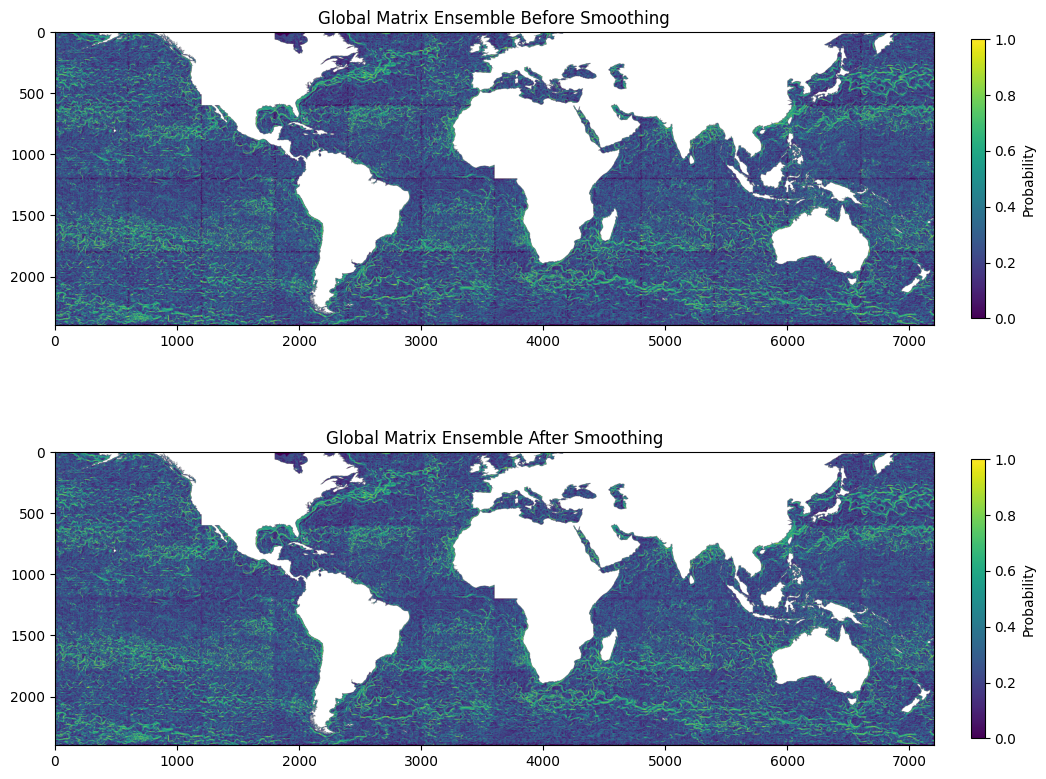

In [16]:
import matplotlib.pyplot as plt

# plot the global matrix before and after smoothing
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.title('Global Matrix Ensemble Before Smoothing')
plt.imshow(global_matrix_ensemble, cmap='viridis', origin='upper')
plt.colorbar(label='Probability', fraction=0.015, pad=0.04)
plt.subplot(2, 1, 2)
plt.title('Global Matrix Ensemble After Smoothing')
plt.imshow(global_matrix_ensemble_smoothed, cmap='viridis', origin='upper')
plt.colorbar(label='Probability', fraction=0.015, pad=0.04)
plt.show()

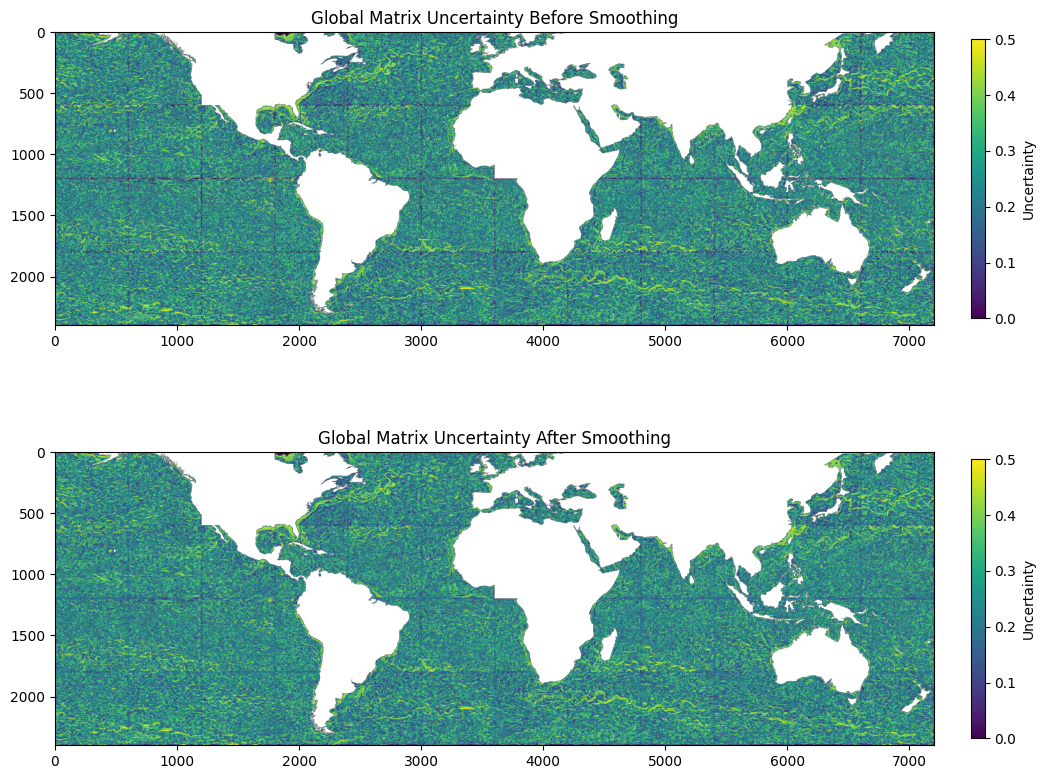

In [17]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.title('Global Matrix Uncertainty Before Smoothing')
plt.imshow(global_matrix_uncertainty, cmap='viridis', origin='upper')
plt.colorbar(label='Uncertainty', fraction=0.015, pad=0.04)
plt.subplot(2, 1, 2)
plt.title('Global Matrix Uncertainty After Smoothing')
plt.imshow(global_matrix_uncertainty_smoothed, cmap='viridis', origin='upper')
plt.colorbar(label='Uncertainty', fraction=0.015, pad=0.04)
plt.show()